# Energy Prediction Model for House Energy Consumption Optimization

This study presents a deep learning-based approach in a manner that used the Long Short-Term Memory (LSTM) algorithm to determine energy consumption behavior patterns using historical power usage data.


Scope and objectives
Build using machine learning models to predict power consumption for following periods using historical power usage data
	-Intraday power consumption Interval of 8 hours.
	-Daily Power consumption.
	-Fortnight Power consumption.


Answer the following set of research questions though statical analysis.
Research Question 1 (RQ1):

Household energy consumption prediction using machine learning.
Null Hypothesis(H0): Household energy consumption cannot be predicted using machine learning.

Alternate Hypothesis (HA): Household energy consumption can be predicted using machine learning.

Research Question 2 (RQ2):
Household energy demand trend analysis.
Null Hypothesis(H0): Household energy requirement increases every year.
Alternate Hypothesis (HA): Household energy requirements do not increase
every year.

Research Question 3 (RQ3):
Household energy consumption distributes across sub metering areas.
Null Hypothesis(H0): Energy consumed in submetering areas of the houses are different.

Alternate Hypothesis (HA): Energy consumed in different submetering of the houses are equal.

Research Question 4 (RQ4):
Household energy consumption Seasonality Trend analysis.

Null Hypothesis(H0): Consumers’ electrical consumption is constant in each
month of the year.

Alternate Hypothesis (HA): Consumers’ electrical consumption varies in each month of year.



Data Set

Reference to the data source with URLs
https://archive.ics.uci.edu/
Individual Household Electric Power Consumption - UCI Machine Learning Repository


The dataset comprises multi electrical parameters, which include

Date,

Time,

Global Active Power,

Global Reactive Power,

Voltage,
Global Intensity,

Sub-metering 1,

Sub-metering 2,

and Sub-metering 3.

In [1]:
import pandas as pd
import numpy as np

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
df = pd.read_csv("/content/drive/My Drive/Colab Notebooks/DBA/household_power_consumption.csv")
df

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0
...,...,...,...,...,...,...,...,...,...
2075254,26/11/2010,20:58:00,0.946,0.0,240.43,4.0,0.0,0.0,0.0
2075255,26/11/2010,20:59:00,0.944,0.0,240.0,4.0,0.0,0.0,0.0
2075256,26/11/2010,21:00:00,0.938,0.0,239.82,3.8,0.0,0.0,0.0
2075257,26/11/2010,21:01:00,0.934,0.0,239.7,3.8,0.0,0.0,0.0


In [6]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [7]:
df.tail()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
2075254,26/11/2010,20:58:00,0.946,0.0,240.43,4.0,0.0,0.0,0.0
2075255,26/11/2010,20:59:00,0.944,0.0,240.0,4.0,0.0,0.0,0.0
2075256,26/11/2010,21:00:00,0.938,0.0,239.82,3.8,0.0,0.0,0.0
2075257,26/11/2010,21:01:00,0.934,0.0,239.7,3.8,0.0,0.0,0.0
2075258,26/11/2010,21:02:00,0.932,0.0,239.55,3.8,0.0,0.0,0.0


In [8]:
df.shape

(2075259, 9)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    object 
 3   Global_reactive_power  object 
 4   Voltage                object 
 5   Global_intensity       object 
 6   Sub_metering_1         object 
 7   Sub_metering_2         object 
 8   Sub_metering_3         float64
dtypes: float64(1), object(8)
memory usage: 142.5+ MB


In [10]:
print(df.info(), "\n")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    object 
 3   Global_reactive_power  object 
 4   Voltage                object 
 5   Global_intensity       object 
 6   Sub_metering_1         object 
 7   Sub_metering_2         object 
 8   Sub_metering_3         float64
dtypes: float64(1), object(8)
memory usage: 142.5+ MB
None 



In [11]:
df.isnull().sum()

,0
Date,0
Time,0
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,25979


Observation:

There are 25979 null values in Sub_metering_3 observation.


In [12]:
df_clean = df.dropna(subset=['Sub_metering_3'])

In [13]:
df_clean.shape

(2049280, 9)

Observation:

There are 2049280 observations after dropping null values observations.

Check for Duplicate

In [14]:
df_clean.duplicated().sum()

np.int64(0)

Observation:

There are no duplicate observation found in the data set.

In [15]:
df_clean.columns

Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')

In [16]:
df_clean['Global_active_power'] = df_clean['Global_active_power'].replace('?', np.nan).astype(float)
df_clean['Global_reactive_power'] = df_clean['Global_reactive_power'].replace('?', np.nan).astype(float)
df_clean['Voltage'] = df_clean['Voltage'].replace('?', np.nan).astype(float)
df_clean['Global_intensity'] = df_clean['Global_intensity'].replace('?', np.nan).astype(float)
df_clean['Sub_metering_1'] = df_clean['Sub_metering_1'].replace('?', np.nan).astype(float)
df_clean['Sub_metering_2'] = df_clean['Sub_metering_2'].replace('?', np.nan).astype(float)

In [27]:
df_clean['Date']=pd.to_datetime(df_clean['Date'],dayfirst=True);

In [28]:
df_clean['Month']=df_clean['Date'].dt.month
df_clean['Day']=df_clean['Date'].dt.day
df_clean['Year']=df_clean['Date'].dt.year

In [18]:
#print the first rows for the cleaned data set
df_clean.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,2006-12-16,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,2006-12-16,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,2006-12-16,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,2006-12-16,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


Created new feature column as Total_consumption

In [19]:
df_clean['Total_consumption'] = df_clean['Sub_metering_1'] + df_clean['Sub_metering_2'] + df_clean['Sub_metering_3']

In [20]:
df_clean.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Total_consumption
0,2006-12-16,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,18.0
1,2006-12-16,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,17.0
2,2006-12-16,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,19.0
3,2006-12-16,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,18.0
4,2006-12-16,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,18.0


Perform Statistical analysis of the Observations

In [21]:
from numpy._core import numeric
print("\nSummary Table Generated by .describe() Method:")
print(df_clean.describe(include=float))


Summary Table Generated by .describe() Method:
       Global_active_power  Global_reactive_power       Voltage  \
count         2.049280e+06           2.049280e+06  2.049280e+06   
mean          1.091615e+00           1.237145e-01  2.408399e+02   
std           1.057294e+00           1.127220e-01  3.239987e+00   
min           7.600000e-02           0.000000e+00  2.232000e+02   
25%           3.080000e-01           4.800000e-02  2.389900e+02   
50%           6.020000e-01           1.000000e-01  2.410100e+02   
75%           1.528000e+00           1.940000e-01  2.428900e+02   
max           1.112200e+01           1.390000e+00  2.541500e+02   

       Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  \
count      2.049280e+06    2.049280e+06    2.049280e+06    2.049280e+06   
mean       4.627759e+00    1.121923e+00    1.298520e+00    6.458447e+00   
std        4.444396e+00    6.153031e+00    5.822026e+00    8.437154e+00   
min        2.000000e-01    0.000000e+00    0.000

Observations:



In [22]:
print(df_clean.info(), "\n")

<class 'pandas.core.frame.DataFrame'>
Index: 2049280 entries, 0 to 2075258
Data columns (total 10 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Date                   datetime64[ns]
 1   Time                   object        
 2   Global_active_power    float64       
 3   Global_reactive_power  float64       
 4   Voltage                float64       
 5   Global_intensity       float64       
 6   Sub_metering_1         float64       
 7   Sub_metering_2         float64       
 8   Sub_metering_3         float64       
 9   Total_consumption      float64       
dtypes: datetime64[ns](1), float64(8), object(1)
memory usage: 172.0+ MB
None 



In [25]:
df_clean.dtypes

,0
Date,datetime64[ns]
Time,object
Global_active_power,float64
Global_reactive_power,float64
Voltage,float64
Global_intensity,float64
Sub_metering_1,float64
Sub_metering_2,float64
Sub_metering_3,float64
Total_consumption,float64


In [29]:
print("")
print("Total Number of Years: ", df_clean.Year.nunique() )
print(df_clean.Year.unique())


Total Number of Years:  5
[2006 2007 2008 2009 2010]


Observation:

There are total 5 years of data present in the data set(Year 2006 till Year 2020)

Exploratory Data Analysis

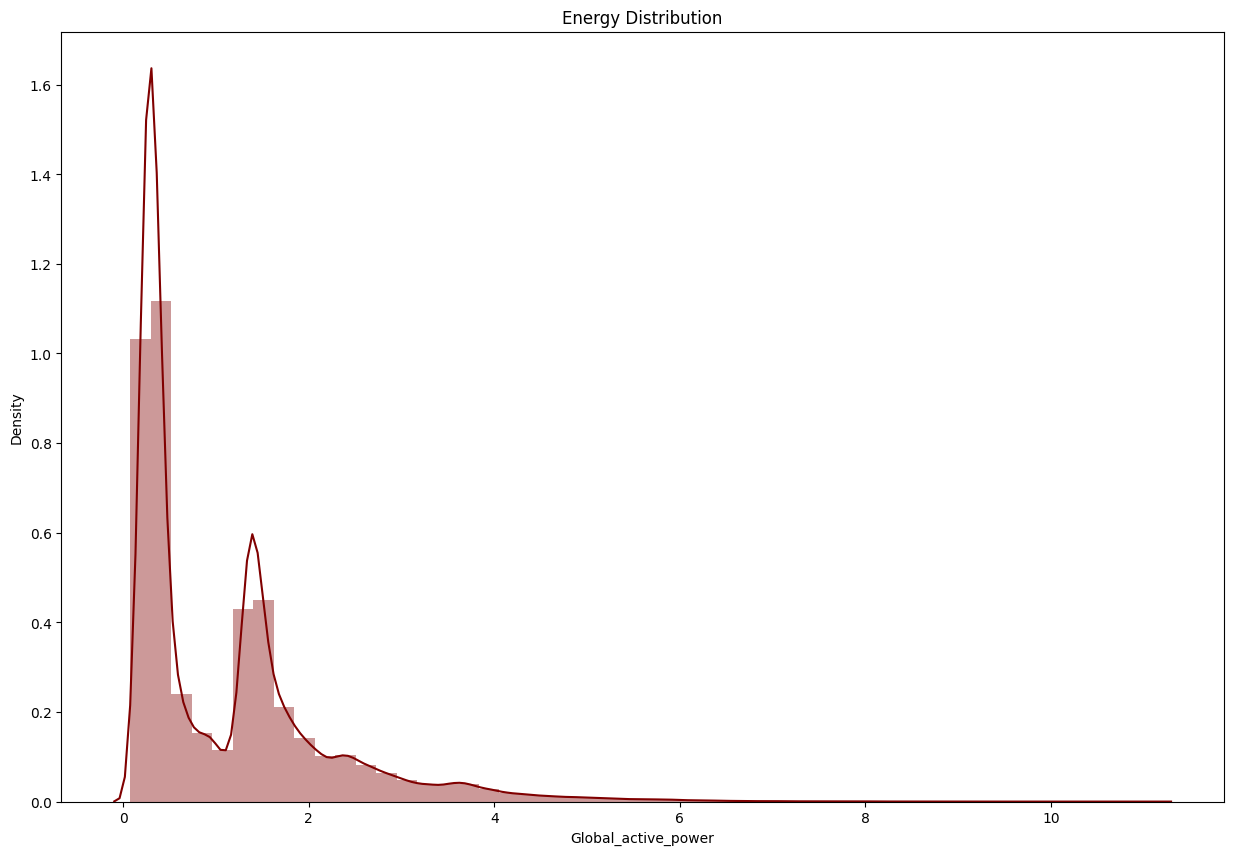

In [51]:
# Lets us see the Distribution off Energy Consumption so we have a idea about your Dataset a bit more
fig = plt.figure(figsize = (15,10))
sns.distplot(df_clean["Global_active_power"],color='maroon')
plt.title("Energy Distribution");

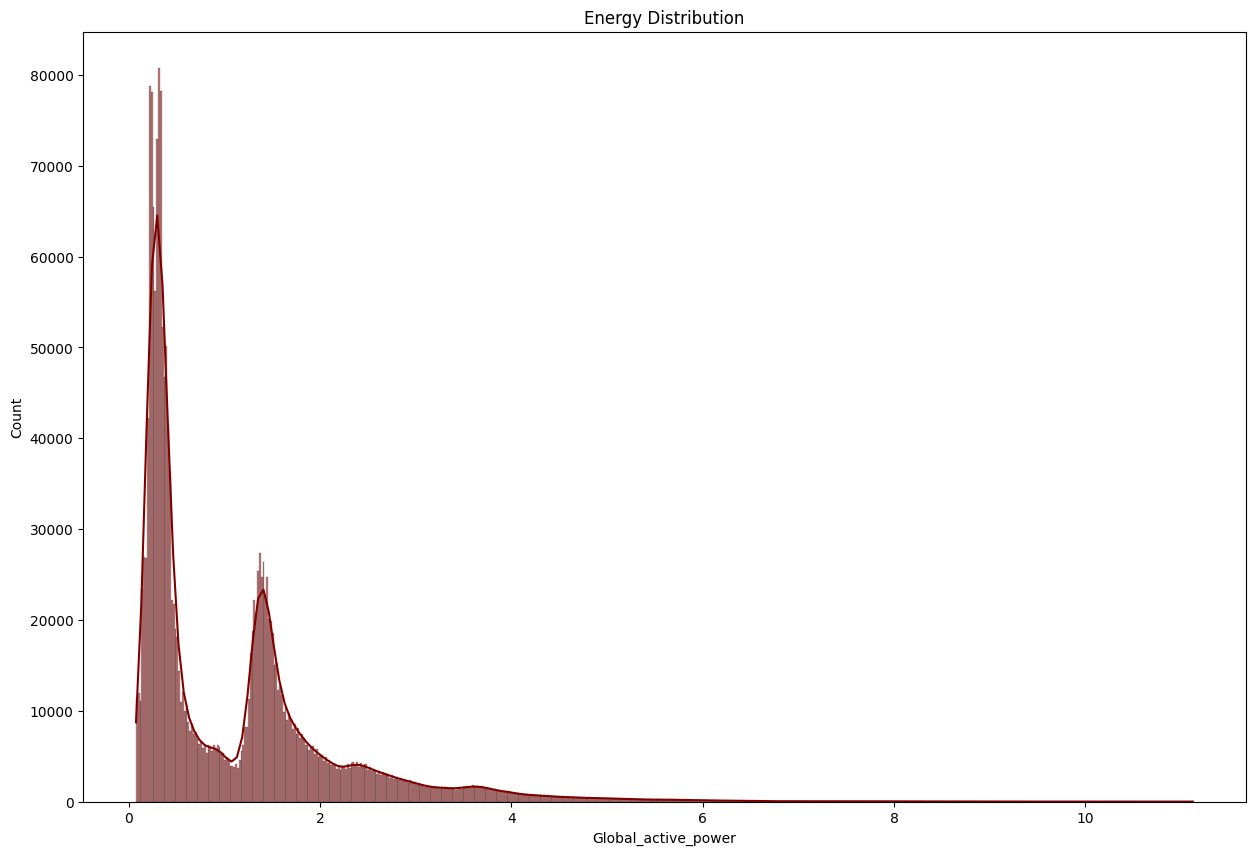

In [52]:
# Lets us see the Distribution off Energy Consumption so we have a idea about your Dataset a bit more
fig = plt.figure(figsize = (15,10))
sns.histplot(df_clean["Global_active_power"], kde=True,color='maroon')
plt.title("Energy Distribution");

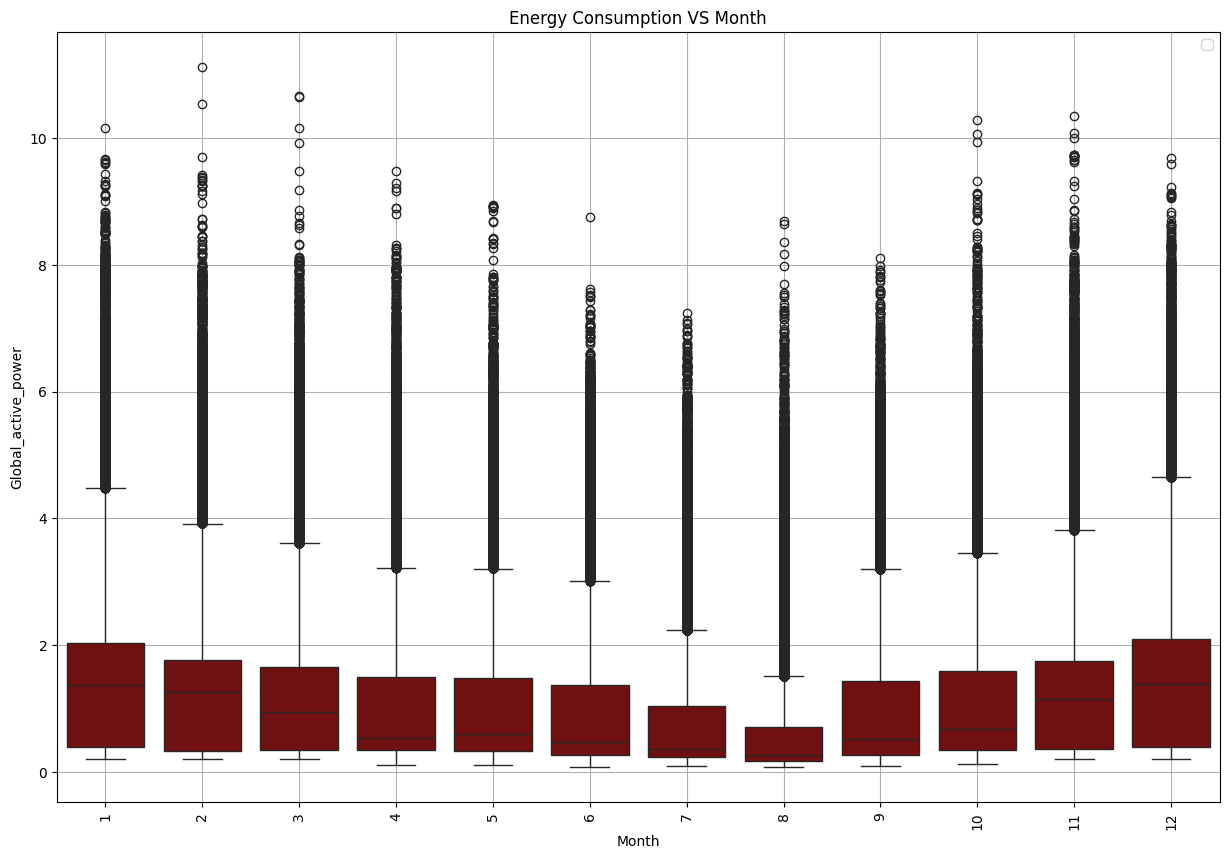

In [53]:
fig = plt.figure(figsize = (15,10))
sns.boxplot(x=df_clean["Month"], y=df_clean["Global_active_power"],data= df_clean,color='maroon')
plt.title("Energy Consumption VS Month")
plt.xlabel("Month")
plt.grid(True, alpha=1)
plt.legend()

ax = plt.gca() # Get the current axes
for label in ax.xaxis.get_ticklabels():
    label.set_rotation(90);

In [93]:
year_totalConsumption= df_clean.groupby('Year')['Global_active_power'].sum()

In [95]:
year_totalConsumption

,Global_active_power
Year,
2006,41813.282
2007,582708.186
2008,564893.094
2009,562315.198
2010,485295.102


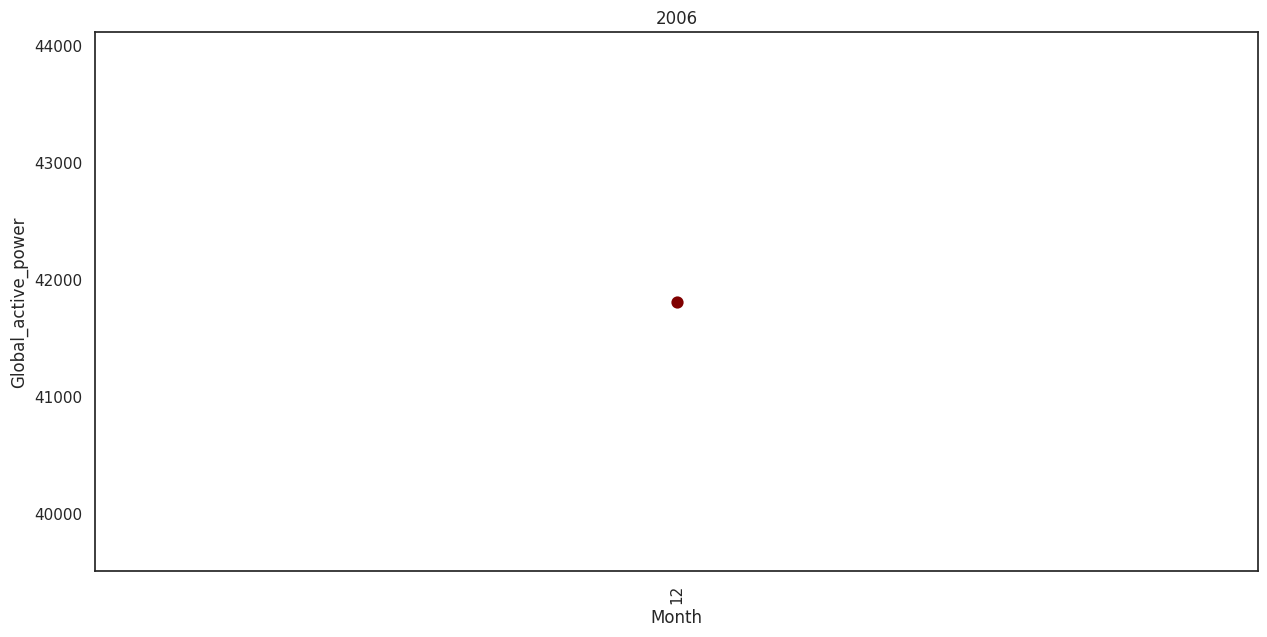

In [96]:
plt.figure(figsize=(15, 7))
sns.pointplot(x='Month', y='Global_active_power', data=df_2006, estimator=sum, errorbar=None,color='maroon')
plt.xticks(rotation=90);
plt.title('2006');

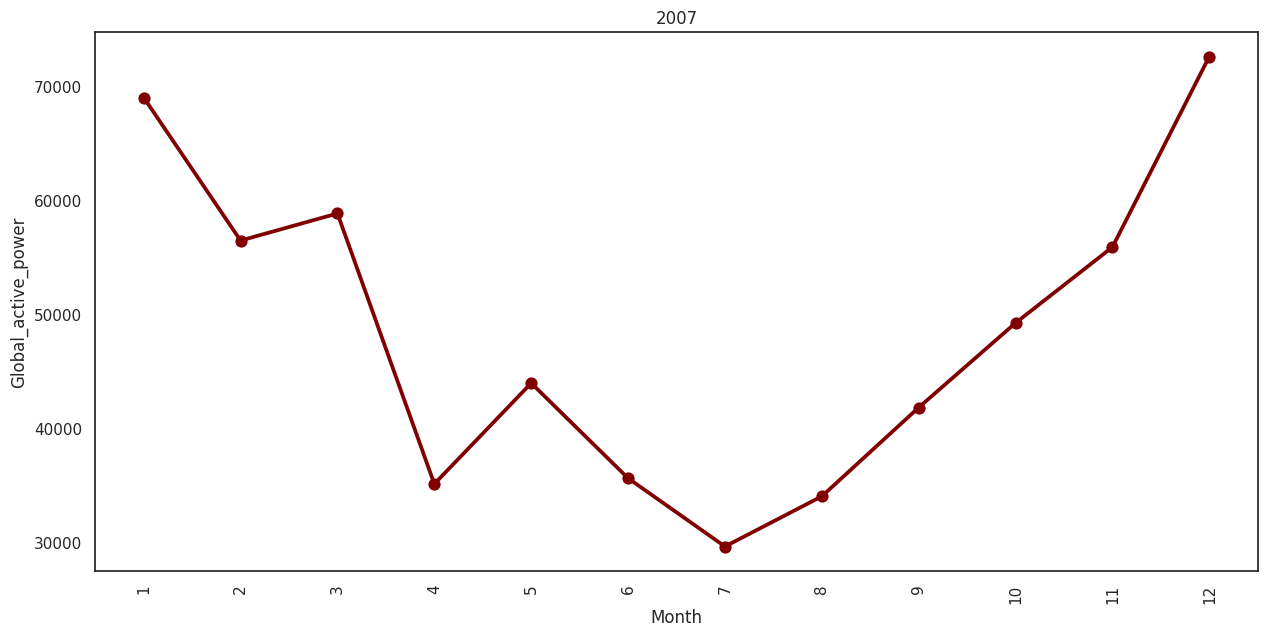

In [97]:
plt.figure(figsize=(15, 7))
sns.pointplot(x='Month', y='Global_active_power', data=df_2007, estimator=sum, errorbar=None,color='maroon')
plt.xticks(rotation=90);
plt.title('2007');

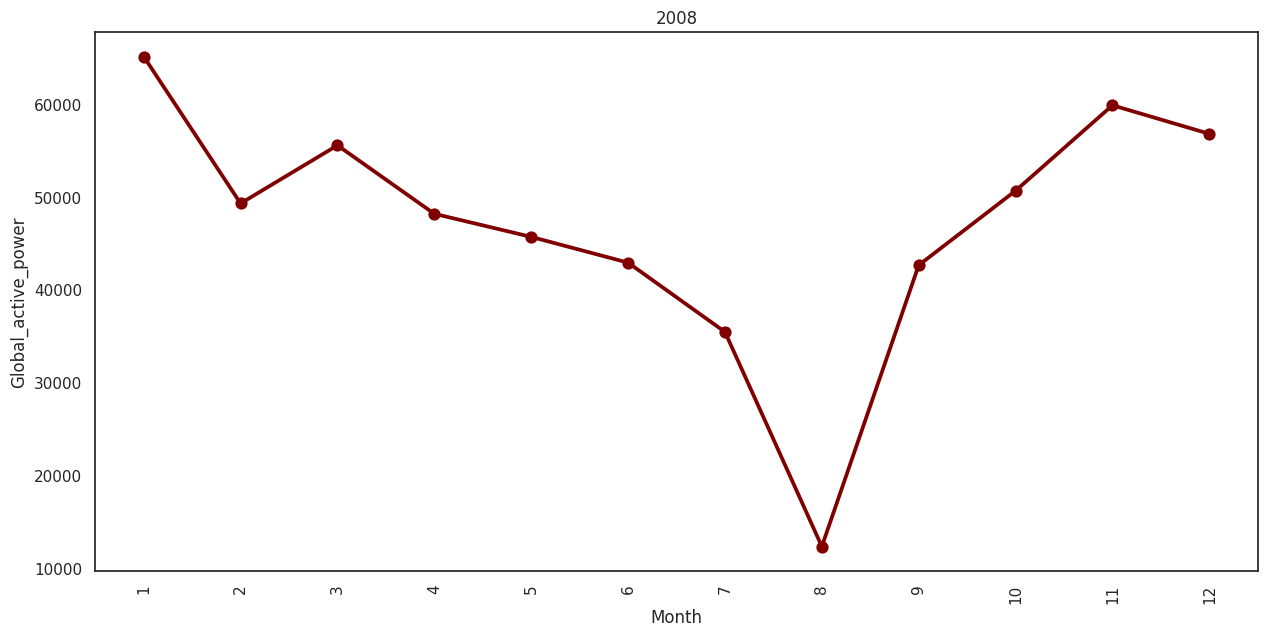

In [105]:
plt.figure(figsize=(15, 7))
sns.pointplot(x='Month', y='Global_active_power', data=df_2008, estimator=sum, errorbar=None,color='maroon')
plt.xticks(rotation=90);
plt.title('2008');

Plot x axit month, separate  lines for different years
Plot for all month and all years

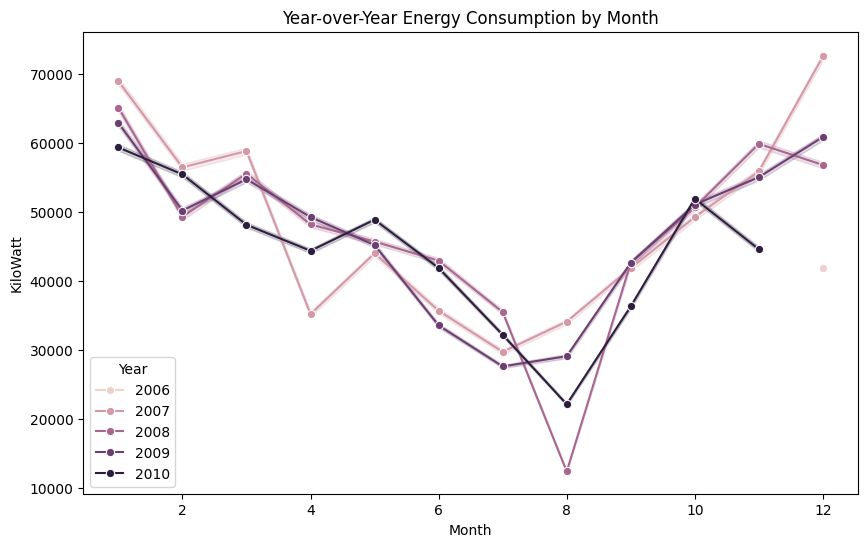

In [62]:
# 2. Plot with years as separate lines
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_clean, x='Month', y='Global_active_power', estimator=sum,hue='Year', marker='o')
plt.title('Year-over-Year Energy Consumption by Month')
plt.xlabel("Month")
plt.ylabel("KiloWatt")
plt.legend(title='Year')
plt.show();

TODO: Convert the 1 week data to meet the objective of 7 days view: Model 1


Intraday power consumption
Neartime: Interval of 8 hours(): Model 2


Daily Power consumption

Feature can be : What time of the Day




In [64]:
# ---  Dictionary of day-wise DataFrames ---
day_wise_dfs = {
    day: group.reset_index(drop=True)
    for day, group in df_clean.groupby(df_clean['Date'].dt.date)
}

In [71]:
# Get the first key (date) from the dictionary
first_day = next(iter(day_wise_dfs.keys()))

# Access the DataFrame for the first day and display its head
day_wise_dfs[first_day].head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Total_consumption,Month,Day,Year
0,2006-12-16,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,18.0,12,16,2006
1,2006-12-16,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,17.0,12,16,2006
2,2006-12-16,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,19.0,12,16,2006
3,2006-12-16,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,18.0,12,16,2006
4,2006-12-16,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,18.0,12,16,2006


In [72]:
print(day_wise_dfs.keys())

dict_keys([datetime.date(2006, 12, 16), datetime.date(2006, 12, 17), datetime.date(2006, 12, 18), datetime.date(2006, 12, 19), datetime.date(2006, 12, 20), datetime.date(2006, 12, 21), datetime.date(2006, 12, 22), datetime.date(2006, 12, 23), datetime.date(2006, 12, 24), datetime.date(2006, 12, 25), datetime.date(2006, 12, 26), datetime.date(2006, 12, 27), datetime.date(2006, 12, 28), datetime.date(2006, 12, 29), datetime.date(2006, 12, 30), datetime.date(2006, 12, 31), datetime.date(2007, 1, 1), datetime.date(2007, 1, 2), datetime.date(2007, 1, 3), datetime.date(2007, 1, 4), datetime.date(2007, 1, 5), datetime.date(2007, 1, 6), datetime.date(2007, 1, 7), datetime.date(2007, 1, 8), datetime.date(2007, 1, 9), datetime.date(2007, 1, 10), datetime.date(2007, 1, 11), datetime.date(2007, 1, 12), datetime.date(2007, 1, 13), datetime.date(2007, 1, 14), datetime.date(2007, 1, 15), datetime.date(2007, 1, 16), datetime.date(2007, 1, 17), datetime.date(2007, 1, 18), datetime.date(2007, 1, 19), da

In [73]:
len((day_wise_dfs.keys()))

1433

Feature Extraction

In [76]:
df_clean.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Total_consumption,Month,Day,Year
0,2006-12-16,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,18.0,12,16,2006
1,2006-12-16,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,17.0,12,16,2006
2,2006-12-16,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,19.0,12,16,2006
3,2006-12-16,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,18.0,12,16,2006
4,2006-12-16,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,18.0,12,16,2006


In [85]:
df_date = df_clean.groupby([df_clean['Date'].dt.date]).Global_active_power.sum()

In [ ]:
df_date.head()

,Total_consumption
Date_Time,
2006-12-16,5472.0
2006-12-17,19561.0
2006-12-18,17702.0
2006-12-19,14638.0
2006-12-20,16711.0


In [80]:
df_date.tail()

,Global_active_power
Date,
2010-11-22,2041.536
2010-11-23,1577.536
2010-11-24,1796.248
2010-11-25,1431.164
2010-11-26,1488.104


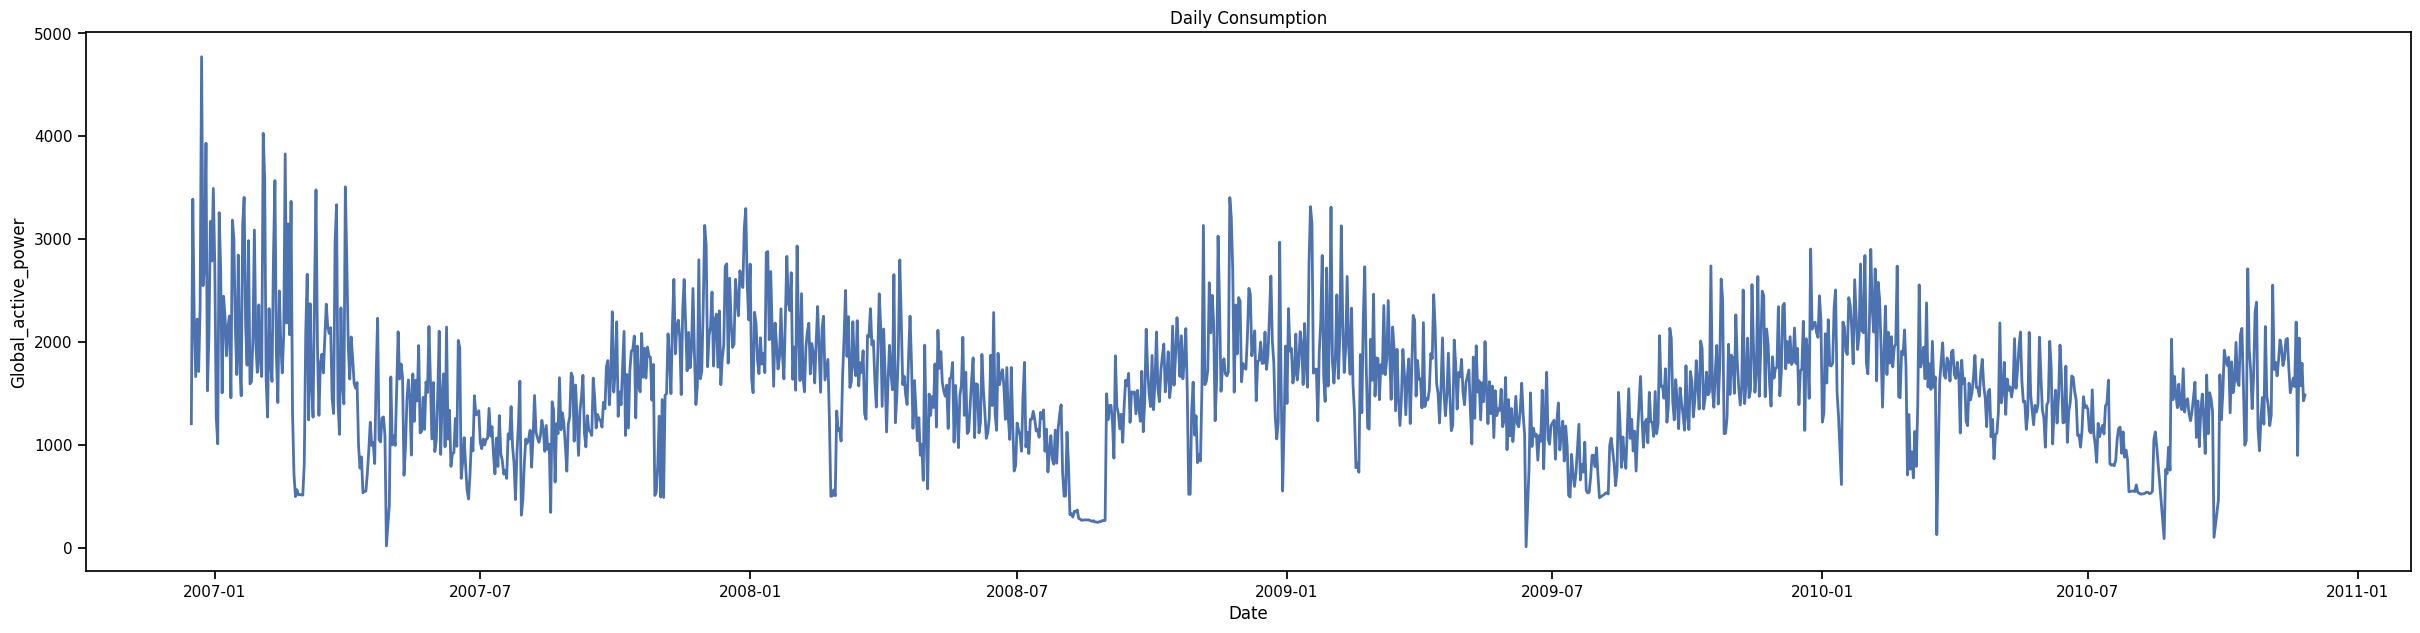

In [81]:
plt.figure(figsize=(30, 7))
sns.set_theme(style=None)
sns.lineplot( data=df_date, linewidth=2);
plt.title("Daily Consumption");

In [86]:
df_month=df_clean.groupby([df_clean['Date'].dt.month]).Global_active_power.sum()

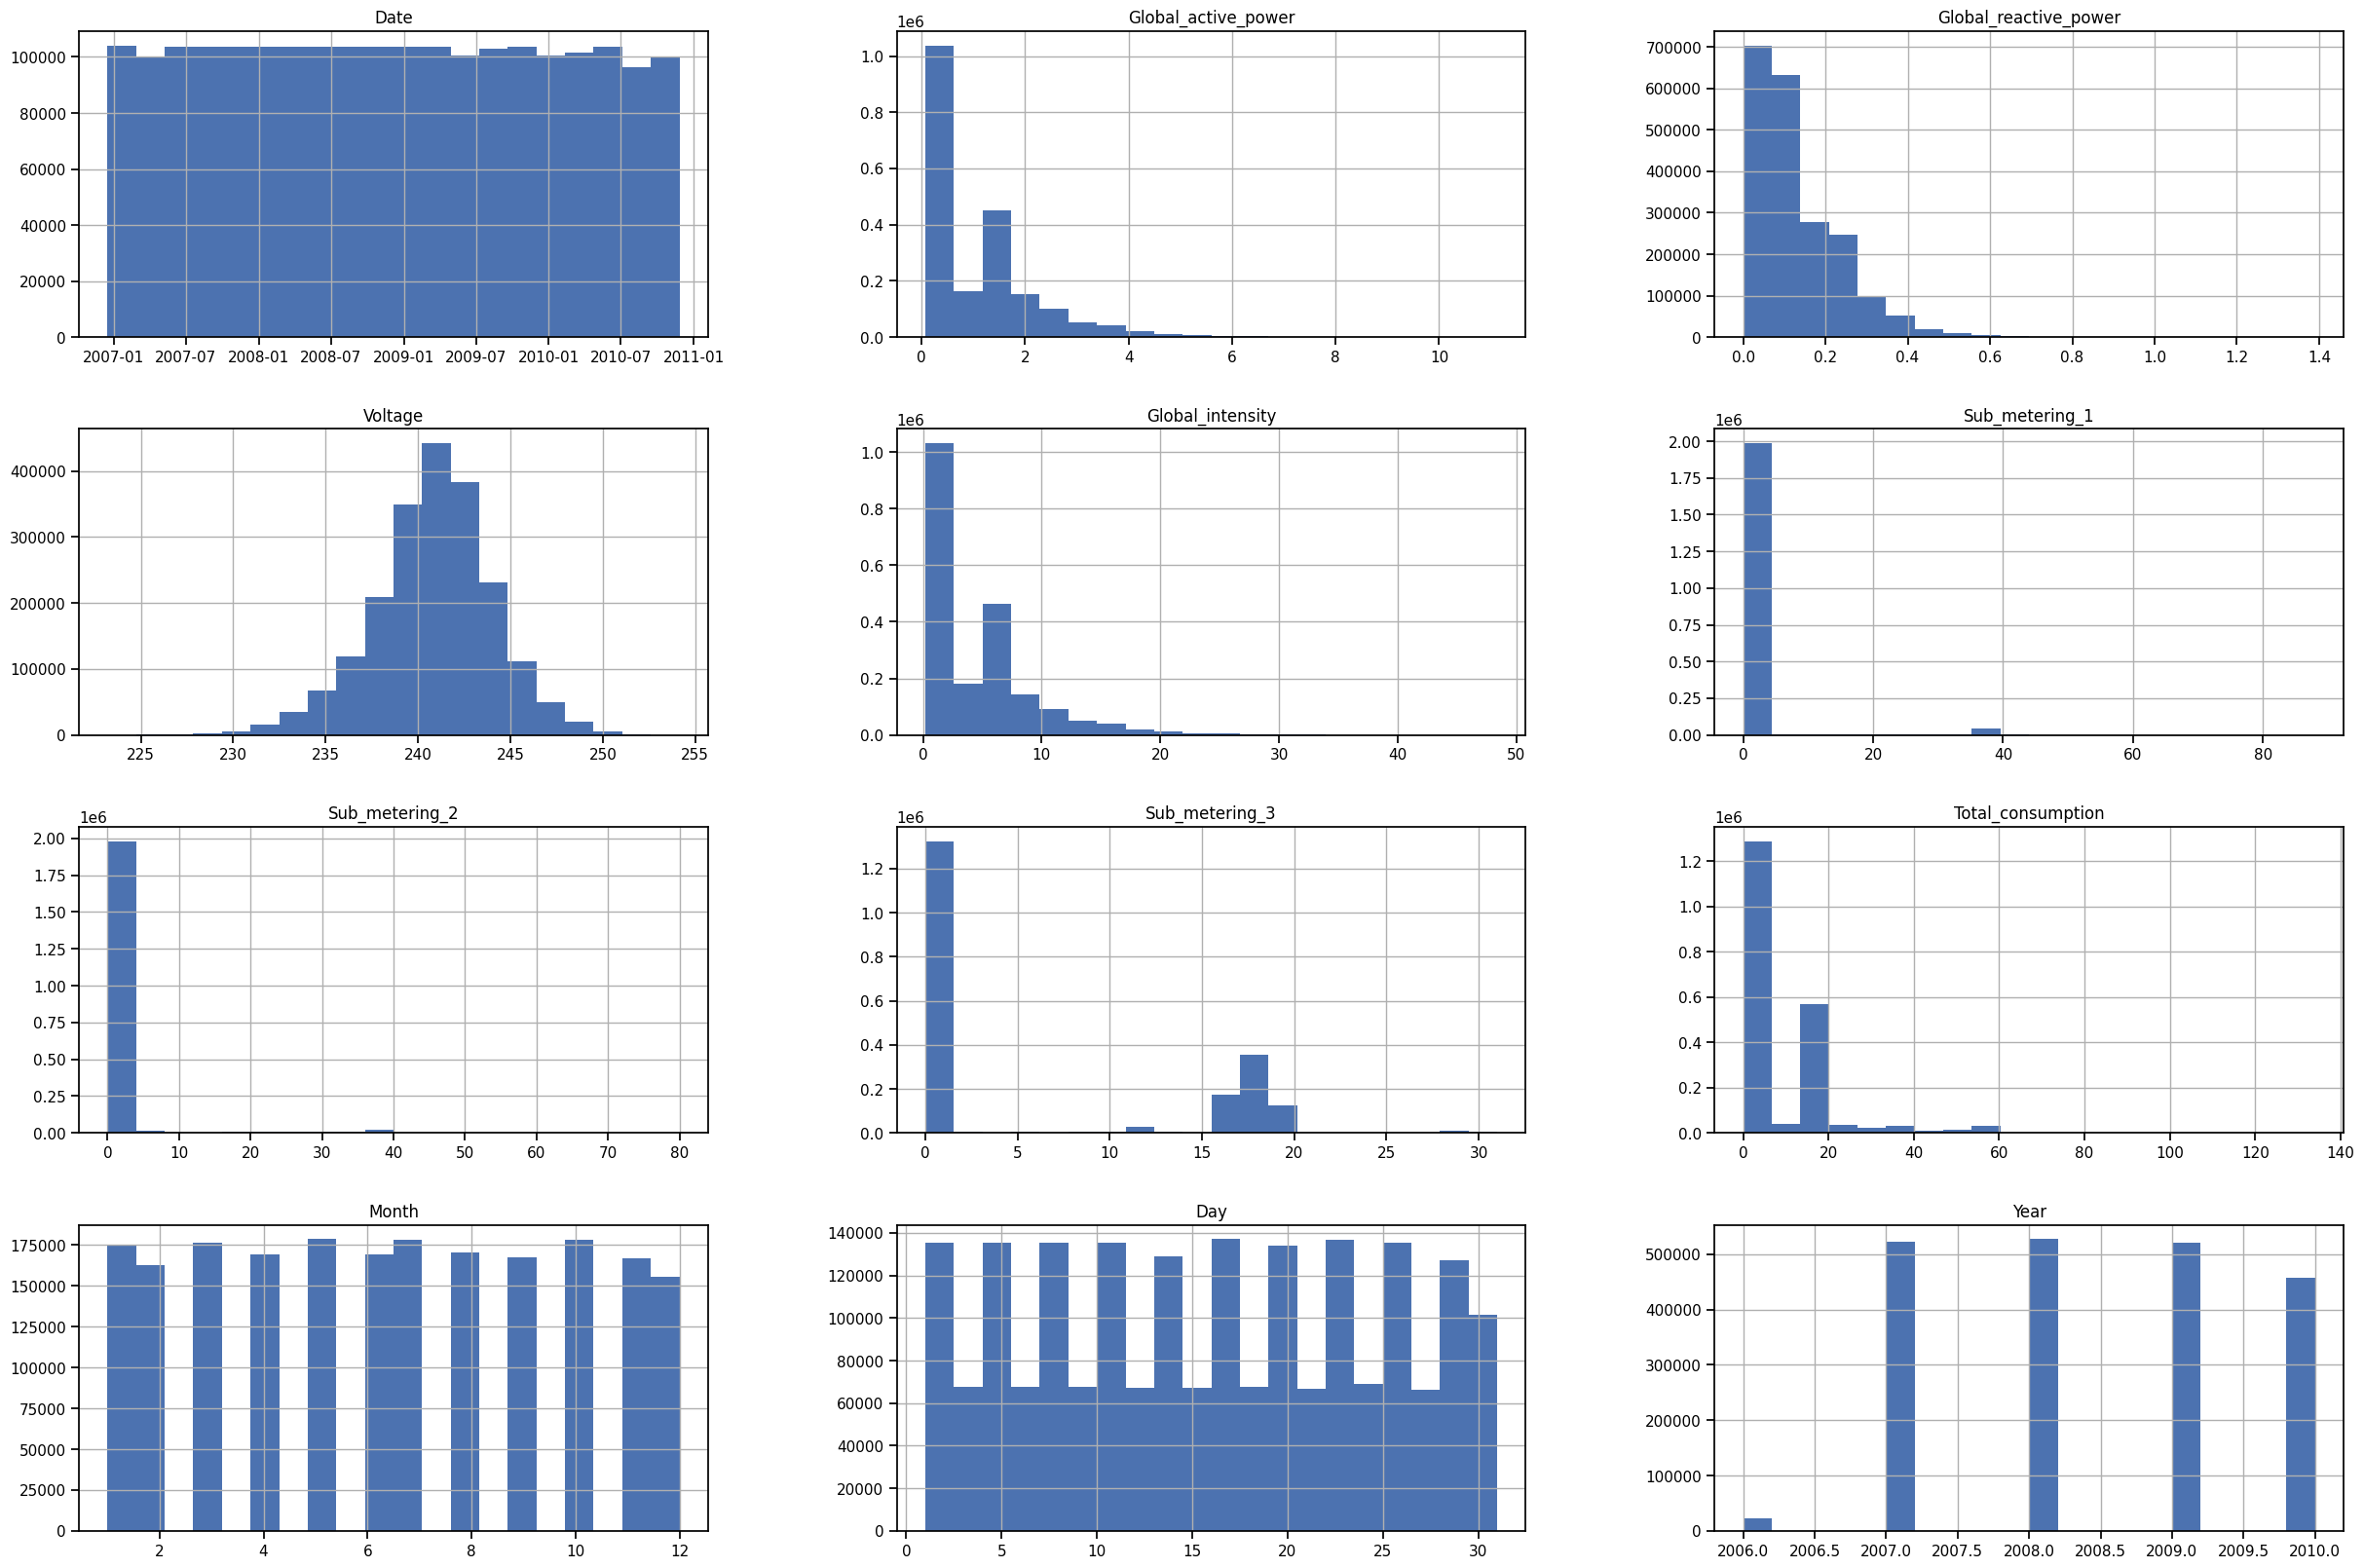

In [87]:

df_clean.hist(bins=20, figsize=(30,20))
plt.show()

Bi-Variate Analysis

<Figure size 2000x700 with 0 Axes>

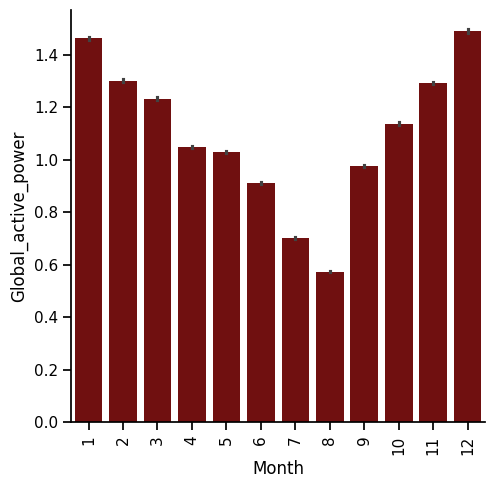

In [89]:
plt.figure(figsize=(20,7));
sns.catplot(data=df_clean,x= 'Month', y='Global_active_power', kind='bar', color='maroon');
plt.xticks(rotation=90);

Multi-Variate Analysis

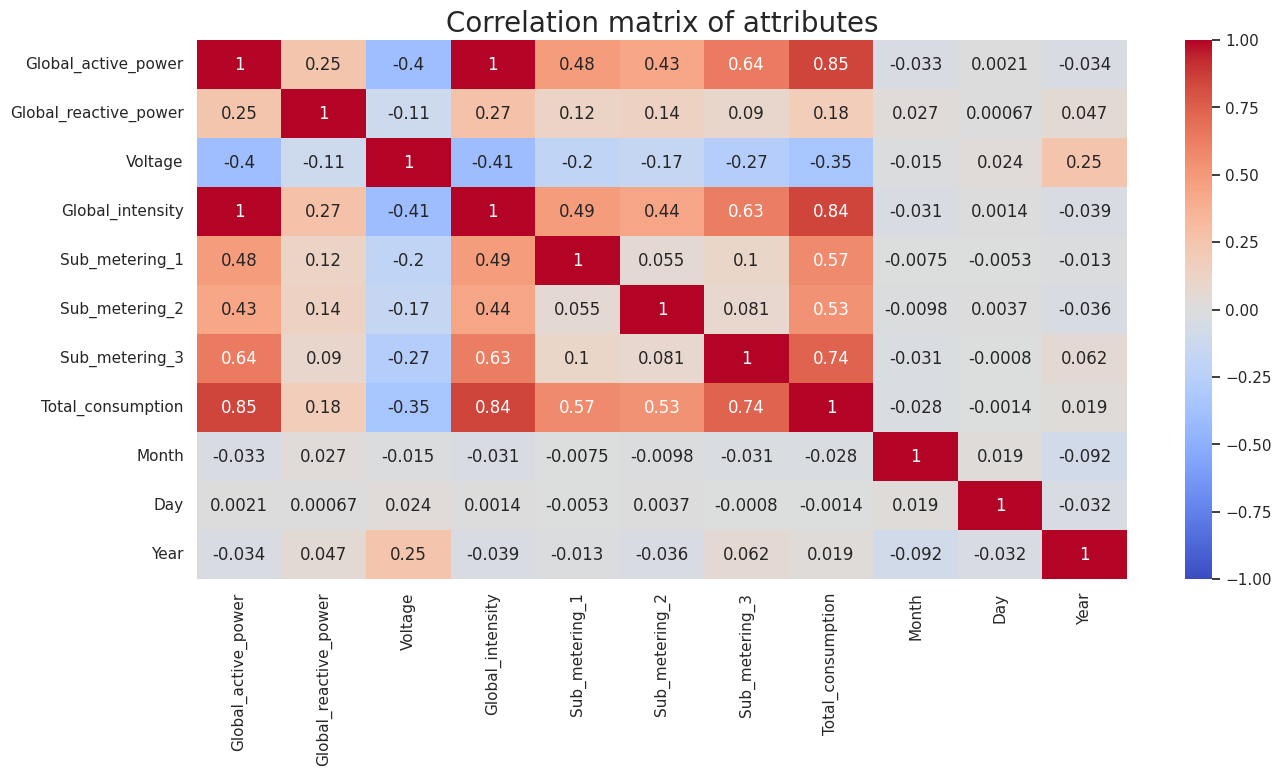

In [90]:
corr_matrix = df_clean.corr(numeric_only=True)

sns.set(style='white')
plt.figure(figsize=(15, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation matrix of attributes', fontsize=20)
plt.show()

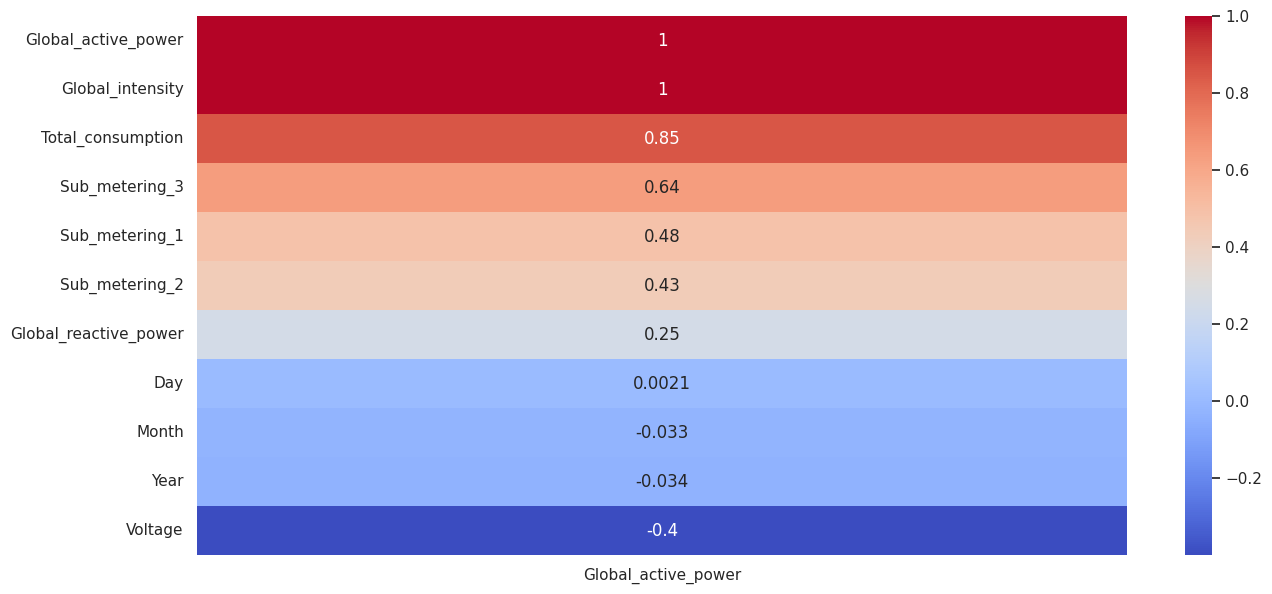

In [91]:
cm = corr_matrix[['Global_active_power']].sort_values(by='Global_active_power', ascending=False)
plt.figure(figsize=(15,7))
sns.heatmap(cm, cmap='coolwarm', annot=True)
plt.show()

In [92]:
cm

,Global_active_power
Global_active_power,1.000000
Global_intensity,0.998889
Total_consumption,0.847252
Sub_metering_3,0.638555
Sub_metering_1,0.484401
Sub_metering_2,0.434569
Global_reactive_power,0.247017
Day,0.002052
Month,-0.032654
Year,-0.034328


Research Question 1 (RQ1):

Household energy consumption prediction using machine learning.

Null Hypothesis(H0): Household energy consumption cannot be predicted using machine learning.

Alternate Hypothesis (HA): Household energy consumption can be predicted using machine learning.

Research Question 2 (RQ2):

Household energy demand weekly trend analysis.

Null Hypothesis(H0): Household energy requirement during week days and week end days are same.

Alternate Hypothesis (HA): Household energy requirements during week days and week end days are different

In [99]:
import pandas as pd
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

# 2. Create Groups (e.g., Weekday vs Weekend)
df_clean['Is_Weekend'] = df_clean['Date'].dt.dayofweek >= 5
group_a = df_clean[df_clean['Is_Weekend'] == False]['Global_active_power'].dropna()
group_b = df_clean[df_clean['Is_Weekend'] == True]['Global_active_power'].dropna()

# 3. Perform Welch's T-Test (does not assume equal variance)
t_stat, p_val = stats.ttest_ind(group_a, group_b, equal_var=False)

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_val}")

T-statistic: -111.57786740682796
P-value: 0.0


Interpretation

Statistical Significance: The P-value of 0.0 is well below the standard alpha threshold (typically 0.05).

 This indicates that the results are highly statistically significant, and we can reject the null hypothesis with near-absolute certainty.

Direction of Difference: The negative T-statistic (-111.57) suggests that the mean of the first group is substantially lower than the mean of the second group.



Research Question 3 (RQ3):

Household energy consumption distributes across sub metering areas.

Null Hypothesis(H0): Energy consumed in submetering areas of the houses are different.

Alternate Hypothesis (HA): Energy consumed in different submetering of the houses are equal.




In [100]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Melt zones into a single categorical column for comparison
df_melt = pd.melt(df_clean, value_vars=['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3'],
                 var_name='Zone', value_name='Consumption')

# 2. Fit ANOVA Model
model = ols('Consumption ~ C(Zone)', data=df_melt).fit()
anova_result = sm.stats.anova_lm(model, typ=2)

print(anova_result)

                sum_sq         df              F  PR(>F)
C(Zone)   3.766203e+07        2.0  395218.323457     0.0
Residual  2.929267e+08  6147837.0            NaN     NaN


Interpretation


Absolute Significance: The P-value of 0.0 indicates that the probability of these results occurring by random chance is effectively zero.

 We can reject the null hypothesis with total confidence.Significant Group Differences: There is a statistically significant difference in energy consumption between the different sub-metering zones.

 Magnitude of Effect: The exceptionally large F-statistic (395,218) suggests that the "Zone" category is a very powerful predictor of energy usage. The variation between the zones is far greater than the noise or variation within each individual zone.

 Sample Scale: The large number of residual degrees of freedom ($>6$ million) indicates this analysis was performed on a high-frequency or long-term dataset, likely covering many months or years of minute-by-minute energy readings.

Research Question 4 (RQ4):

Household energy consumption Seasonality Trend analysis.

Null Hypothesis(H0): Consumers’ electrical consumption is constant in each month of the year.

Alternate Hypothesis (HA): Consumers’ electrical consumption varies in each month of year.

In [104]:
# 1. Feature Engineering: Extract Month
df_clean['Month_Name'] = df_clean['Date'].dt.month_name()

# 2. Fit the ANOVA Model
# Hypothesis: Global_active_power is a function of the Month
model = ols('Global_active_power ~ C(Month_Name)', data=df_clean).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

# 3. Output Results
print(anova_table)

                     sum_sq         df             F  PR(>F)
C(Month_Name)  1.484706e+05       11.0  12910.835765     0.0
Residual       2.142359e+06  2049268.0           NaN     NaN


Rejection of the Null Hypothesis: Since the P-value is 0.0 (well below the $\alpha = 0.05$ threshold), we strictly reject the null hypothesis that consumers' electrical consumption is constant throughout the year.

Highly Seasonal Patterns: The large F-statistic suggests that the "Month" is a powerful determinant of energy load. In practical terms, this means the difference between a high-usage month (e.g., July for cooling or December for heating) and a low-usage month is statistically undeniable.

Data Reliability: The high number of residual degrees of freedom indicates that these results are robust and not driven by a few outliers, but rather by a consistent pattern across a massive sample of data points.